<a href="https://colab.research.google.com/github/Anubhavkumar076/ai_data_analysis/blob/main/Cars4U.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Context
There is a huge demand for used cars in the Indian Market today. As sales of new cars have slowed down in the recent past, the pre-owned car market has continued to grow over the past years and is larger than the new car market now. Cars4U is a budding tech start-up that aims to find footholes in this market.

## Objective
You, as a senior data scientist at Cars4U, you have to come up with a pricing model that can effectively predict the price of used cars and can help the business in devising profitable strategies using differential pricing. For example, if the business knows the market price, it will never sell anything below it.

## Data Description
The data contains the different attributes of used cars sold in different locations. The detailed data dictionary is given below.

**Brand**: brand name of the car

**Model Name:** model name of the car

**Location:** Location in which the car is being sold or is available for purchase (cities)

**Year:** Manufacturing year of the car
Kilometers_driven: The total kilometers driven in the car by the previous owner(s) in km

**Fuel_Type:** The type of fuel used by the car (Petrol, Diesel, Electric, CNG, LPG)

**Transmission:** The type of transmission used by the car (Automatic/Manual)

**Owner_Type:** Type of ownership

**Mileage:** The standard mileage offered by the car company in kmpl or km/kg

**Engine:** The displacement volume of the engine in CC

**Power:** The maximum power of the engine in bhp

**Seats:** The number of seats in the car

**New_Price:** The price of a new car of the same model in INR Lakhs (1 Lakh = 100,000 INR)

**Price:** The price of the used car in INR Lakhs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# to split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Let's read the csv data first
cars_df = pd.read_csv('used_cars_data.csv')

Now, we will be do initial data analysis and correction if needed

In [ ]:
cars_df.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,mileage_num,engine_num,power_num,Brand,Model
0,Mumbai,2010,72000.0,CNG,Manual,First,5.0,5.51,1.75,26.60,998.0,58.16,maruti,wagon
1,Pune,2015,41000.0,Diesel,Manual,First,5.0,16.06,12.50,19.67,1582.0,126.20,hyundai,creta
2,Chennai,2011,46000.0,Petrol,Manual,First,5.0,8.61,4.50,18.20,1199.0,88.70,honda,jazz
3,Chennai,2012,87000.0,Diesel,Manual,First,7.0,11.27,6.00,20.77,1248.0,88.76,maruti,ertiga
4,Coimbatore,2013,40670.0,Diesel,Automatic,Second,5.0,53.14,17.74,15.20,1968.0,140.80,audi,a4


In [ ]:
cars_df.tail()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,mileage_num,engine_num,power_num,Brand,Model
7247,Hyderabad,2011,89411.0,Diesel,Manual,First,5.0,13.23,NaN,20.54,1598.0,103.6,volkswagen,vento
7248,Mumbai,2015,59000.0,Petrol,Automatic,First,5.0,10.15,NaN,17.21,1197.0,103.6,volkswagen,polo
7249,Kolkata,2012,28000.0,Diesel,Manual,First,5.0,9.47,NaN,23.08,1461.0,63.1,nissan,micra
7250,Pune,2013,52262.0,Petrol,Automatic,Third,5.0,10.15,NaN,17.20,1197.0,103.6,volkswagen,polo
7251,Kochi,2014,72443.0,Diesel,Automatic,First,5.0,86.97,NaN,10.00,2148.0,170.0,mercedes-benz,e-class


From the above data, we can say there are few entries with missing price. So, we will be checking the missing trend in the data.

In [ ]:
# This will be used to show the row and column counts in this data frame.
cars_df.shape

(7252, 14)

There are **7252** rows and **14** columns

In [ ]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7252 entries, 0 to 7251
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           7252 non-null   object 
 1   Year               7252 non-null   int64  
 2   Kilometers_Driven  7251 non-null   float64
 3   Fuel_Type          7252 non-null   object 
 4   Transmission       7252 non-null   object 
 5   Owner_Type         7252 non-null   object 
 6   Seats              7199 non-null   float64
 7   New_Price          7252 non-null   float64
 8   Price              6019 non-null   float64
 9   mileage_num        7169 non-null   float64
 10  engine_num         7206 non-null   float64
 11  power_num          7077 non-null   float64
 12  Brand              7252 non-null   object 
 13  Model              7252 non-null   object 
dtypes: float64(7), int64(1), object(6)
memory usage: 793.3+ KB


The above data shows that there are *7 numerical* and *6 categorical* columns. There are couple of column having null values.

Column Name          -   Null Values

Kilometers_Driven    -      1

Seats                -      53

Price              - 1233

mileage_num - 83

engine_num - 46

power_num - 175


In [ ]:
# Create a copy of dataframe, so we won't tweak the main data anywhere
df = cars_df.copy()

In [ ]:
# Let's check the nature of these null values one by one
df[df['Kilometers_Driven'].isnull()]


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,mileage_num,engine_num,power_num,Brand,Model
2328,Chennai,2017,NaN,Diesel,Automatic,First,5.0,55.07,65.0,15.97,2993.0,258.0,bmw,x5


In [ ]:
df[ (df['Brand'] == 'bmw') & (df['Model'] == 'x5') ].shape

(25, 14)

In [ ]:
df[ (df['Brand'] == 'bmw') & (df['Model'] == 'x5') ]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,mileage_num,engine_num,power_num,Brand,Model
168,Mumbai,2015,41000.0,Diesel,Automatic,First,5.0,55.07,45.00,15.30,2993.0,258.0,bmw,x5
369,Bangalore,2009,90000.0,Diesel,Automatic,Second,5.0,55.07,17.75,11.00,2993.0,235.0,bmw,x5
516,Hyderabad,2011,75000.0,Diesel,Automatic,First,5.0,55.07,27.50,11.70,2993.0,245.0,bmw,x5
593,Mumbai,2014,19000.0,Diesel,Automatic,First,7.0,55.07,44.00,15.97,2993.0,258.0,bmw,x5
712,Hyderabad,2015,69000.0,Diesel,Automatic,First,5.0,55.07,54.00,15.97,2993.0,258.0,bmw,x5
842,Mumbai,2014,47000.0,Diesel,Automatic,First,7.0,55.07,41.50,15.97,2993.0,258.0,bmw,x5
918,Hyderabad,2016,76000.0,Diesel,Automatic,First,7.0,55.07,58.00,15.97,2993.0,258.0,bmw,x5
1397,Kochi,2016,35659.0,Diesel,Automatic,First,7.0,55.07,43.78,15.97,2993.0,258.0,bmw,x5
1941,Mumbai,2012,66000.0,Diesel,Automatic,First,5.0,55.07,21.00,15.30,2993.0,258.0,bmw,x5
2311,Coimbatore,2016,17738.0,Diesel,Automatic,First,5.0,55.07,54.45,15.30,2993.0,258.0,bmw,x5


There are total 25 entries bor same brand and model, and filling kilometers_driven as trend won't make much sense. So, leaving this entry as it is.

In [ ]:
df[df['Seats'].isnull()]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,mileage_num,engine_num,power_num,Brand,Model
194,Ahmedabad,2007,60006.0,Petrol,Manual,First,NaN,13.580,2.95,NaN,NaN,NaN,honda,city
208,Kolkata,2010,42001.0,Petrol,Manual,First,NaN,7.880,2.11,16.10,NaN,NaN,maruti,swift
229,Bangalore,2015,70436.0,Diesel,Manual,First,NaN,7.650,3.60,NaN,1498.0,99.0,ford,figo
733,Chennai,2006,97800.0,Petrol,Manual,Third,NaN,7.880,1.75,16.10,NaN,NaN,maruti,swift
749,Mumbai,2008,55001.0,Diesel,Automatic,Second,NaN,120.000,26.50,NaN,NaN,NaN,land,rover
1294,Delhi,2009,55005.0,Petrol,Manual,First,NaN,13.580,3.20,12.80,NaN,NaN,honda,city
1327,Hyderabad,2015,50295.0,Petrol,Manual,First,NaN,7.880,5.80,16.10,NaN,NaN,maruti,swift
1385,Pune,2004,115000.0,Petrol,Manual,Second,NaN,13.580,1.50,NaN,NaN,NaN,honda,city
1460,Coimbatore,2008,69078.0,Petrol,Manual,First,NaN,120.000,40.88,NaN,NaN,NaN,land,rover
1917,Jaipur,2005,88000.0,Petrol,Manual,Second,NaN,13.580,1.70,13.00,1493.0,100.0,honda,city


In [ ]:
display(df[df['Seats'].isnull()][['Brand', 'Model']].drop_duplicates().shape)

(16, 2)

In [ ]:
# Impute missing 'Seats' values with the mode for each Brand-Model combination
df['Seats'] = df.groupby(['Brand', 'Model'])['Seats'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

print(f"Number of null values in 'Seats' after imputation: {df['Seats'].isnull().sum()}")

Number of null values in 'Seats' after imputation: 3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7252 entries, 0 to 7251
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           7252 non-null   object 
 1   Year               7252 non-null   int64  
 2   Kilometers_Driven  7251 non-null   float64
 3   Fuel_Type          7252 non-null   object 
 4   Transmission       7252 non-null   object 
 5   Owner_Type         7252 non-null   object 
 6   Seats              7249 non-null   float64
 7   New_Price          7252 non-null   float64
 8   Price              6019 non-null   float64
 9   mileage_num        7169 non-null   float64
 10  engine_num         7206 non-null   float64
 11  power_num          7077 non-null   float64
 12  Brand              7252 non-null   object 
 13  Model              7252 non-null   object 
dtypes: float64(7), int64(1), object(6)
memory usage: 793.3+ KB


In [ ]:
df[df['mileage_num'].isnull()]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,mileage_num,engine_num,power_num,Brand,Model
14,Pune,2012,85000.0,Diesel,Automatic,Second,5.0,120.000,17.50,NaN,2179.0,115.0,land,rover
67,Coimbatore,2019,15369.0,Diesel,Automatic,First,5.0,49.140,35.67,NaN,1950.0,194.0,mercedes-benz,c-class
79,Hyderabad,2005,87591.0,Petrol,Manual,First,5.0,4.550,1.30,NaN,1086.0,NaN,hyundai,santro
194,Ahmedabad,2007,60006.0,Petrol,Manual,First,5.0,13.580,2.95,NaN,NaN,NaN,honda,city
229,Bangalore,2015,70436.0,Diesel,Manual,First,5.0,7.650,3.60,NaN,1498.0,99.0,ford,figo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6632,Kolkata,2016,27000.0,Diesel,Manual,First,7.0,18.865,NaN,NaN,NaN,NaN,mahindra,tuv
6696,Jaipur,2007,85000.0,Petrol,Manual,Second,5.0,4.550,NaN,NaN,1086.0,NaN,hyundai,santro
6856,Mumbai,2011,87000.0,Diesel,Automatic,First,5.0,120.000,NaN,NaN,2179.0,115.0,land,rover
6956,Kochi,2019,11574.0,Petrol,Manual,First,5.0,9.600,NaN,NaN,1199.0,88.7,honda,jazz


In [ ]:
df[ (df['Brand']== 'land') & (df['Model'] == 'rover')]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,mileage_num,engine_num,power_num,Brand,Model
13,Delhi,2014,72000.0,Diesel,Automatic,First,5.0,120.0,27.00,12.70,2179.0,187.70,land,rover
14,Pune,2012,85000.0,Diesel,Automatic,Second,5.0,120.0,17.50,NaN,2179.0,115.00,land,rover
191,Coimbatore,2018,36091.0,Diesel,Automatic,First,5.0,120.0,55.76,12.70,2179.0,187.70,land,rover
311,Delhi,2017,44000.0,Diesel,Automatic,First,5.0,120.0,44.00,12.70,2179.0,187.70,land,rover
399,Hyderabad,2012,56000.0,Diesel,Automatic,First,5.0,120.0,30.00,12.70,2179.0,187.70,land,rover
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6434,Kochi,2012,89190.0,Diesel,Automatic,Second,7.0,120.0,NaN,11.40,2993.0,245.41,land,rover
6716,Kochi,2018,23342.0,Diesel,Automatic,First,5.0,120.0,NaN,12.83,2179.0,147.50,land,rover
6856,Mumbai,2011,87000.0,Diesel,Automatic,First,5.0,120.0,NaN,NaN,2179.0,115.00,land,rover
7156,Hyderabad,2015,49000.0,Diesel,Automatic,Second,5.0,120.0,NaN,12.70,2179.0,187.70,land,rover


In [ ]:
print(f"Null values in 'mileage_num' before imputation: {df['mileage_num'].isnull().sum()}")
df['mileage_num'] = df.groupby(['Brand', 'Model'])['mileage_num'].transform(lambda x: x.fillna(x.median() if not x.isnull().all() else np.nan))
print(f"Null values in 'mileage_num' after imputation: {df['mileage_num'].isnull().sum()}")

Null values in 'mileage_num' before imputation: 83
Null values in 'mileage_num' after imputation: 9


In [ ]:
print(f"Null values in 'engine_num' before imputation: {df['engine_num'].isnull().sum()}")
df['engine_num'] = df.groupby(['Brand', 'Model'])['engine_num'].transform(lambda x: x.fillna(x.median() if not x.isnull().all() else np.nan))
print(f"Null values in 'engine_num' after imputation: {df['engine_num'].isnull().sum()}")

Null values in 'engine_num' before imputation: 46
Null values in 'engine_num' after imputation: 0


In [ ]:
print(f"Null values in 'power_num' before imputation: {df['power_num'].isnull().sum()}")
df['power_num'] = df.groupby(['Brand', 'Model'])['power_num'].transform(lambda x: x.fillna(x.median() if not x.isnull().all() else np.nan))
print(f"Null values in 'power_num' after imputation: {df['power_num'].isnull().sum()}")

Null values in 'power_num' before imputation: 175
Null values in 'power_num' after imputation: 12


Let's check the `df.info()` again to confirm the updated non-null counts.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7252 entries, 0 to 7251
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           7252 non-null   object 
 1   Year               7252 non-null   int64  
 2   Kilometers_Driven  7251 non-null   float64
 3   Fuel_Type          7252 non-null   object 
 4   Transmission       7252 non-null   object 
 5   Owner_Type         7252 non-null   object 
 6   Seats              7249 non-null   float64
 7   New_Price          7252 non-null   float64
 8   Price              6019 non-null   float64
 9   mileage_num        7243 non-null   float64
 10  engine_num         7252 non-null   float64
 11  power_num          7240 non-null   float64
 12  Brand              7252 non-null   object 
 13  Model              7252 non-null   object 
dtypes: float64(7), int64(1), object(6)
memory usage: 793.3+ KB


In [ ]:
df.isnull().sum()

,0
Location,0
Year,0
Kilometers_Driven,1
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,3
New_Price,0
Price,24
mileage_num,9


In [ ]:
df[df['Price'].isnull()].sample()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,mileage_num,engine_num,power_num,Brand,Model
6177,Bangalore,2012,37000.0,Diesel,Automatic,First,5.0,49.49,NaN,14.0,2987.0,165.0,mercedes-benz,m-class


In [ ]:
print(f"Null values in 'Price' before imputation: {df['Price'].isnull().sum()}")
df['Price'] = df.groupby(['Brand', 'Model', 'Owner_Type'])['Price'].transform(lambda x: x.fillna(x.median() if not x.isnull().all() else np.nan))
print(f"Null values in 'Price' after imputation: {df['Price'].isnull().sum()}")

Null values in 'Price' before imputation: 1233
Null values in 'Price' after imputation: 24


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7252 entries, 0 to 7251
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           7252 non-null   object 
 1   Year               7252 non-null   int64  
 2   Kilometers_Driven  7251 non-null   float64
 3   Fuel_Type          7252 non-null   object 
 4   Transmission       7252 non-null   object 
 5   Owner_Type         7252 non-null   object 
 6   Seats              7249 non-null   float64
 7   New_Price          7252 non-null   float64
 8   Price              7228 non-null   float64
 9   mileage_num        7243 non-null   float64
 10  engine_num         7252 non-null   float64
 11  power_num          7240 non-null   float64
 12  Brand              7252 non-null   object 
 13  Model              7252 non-null   object 
dtypes: float64(7), int64(1), object(6)
memory usage: 793.3+ KB


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df[df.duplicated(keep=False) == True]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,mileage_num,engine_num,power_num,Brand,Model
3623,Hyderabad,2007,52195.0,Petrol,Manual,First,5.0,4.36,1.75,19.7,796.0,46.3,maruti,alto
4781,Hyderabad,2007,52195.0,Petrol,Manual,First,5.0,4.36,1.75,19.7,796.0,46.3,maruti,alto
6940,Kolkata,2017,13000.0,Diesel,Manual,First,5.0,13.58,5.91,26.0,1498.0,98.6,honda,city
7077,Kolkata,2017,13000.0,Diesel,Manual,First,5.0,13.58,5.91,26.0,1498.0,98.6,honda,city


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df[df.duplicated(keep=False) == True]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,mileage_num,engine_num,power_num,Brand,Model


In [ ]:
df.shape

(7250, 14)

In [ ]:
df.isnull().sum()

,0
Location,0
Year,0
Kilometers_Driven,1
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,3
New_Price,0
Price,24
mileage_num,9


In [ ]:
df["Seats"] = df["Seats"].fillna(5.0) #Maruti Estilo can accommodate 5 people.

In [ ]:
cols_list = ["Kilometers_Driven","mileage_num", "engine_num", "power_num"]

for col in cols_list:
    df[col] = df.groupby(["Brand", "Model"])[col].transform(
        lambda x: x.fillna(x.median())
    )

df.isnull().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,0
New_Price,0
Price,24
mileage_num,9


In [ ]:
cols_list = ["mileage_num", "power_num"]

for col in cols_list:
    df[col] = df.groupby(["Brand"])[col].transform(
        lambda x: x.fillna(x.median())
    )

df.isnull().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,0
New_Price,0
Price,24
mileage_num,1


In [ ]:
cols_list = ["mileage_num", "power_num"]

for col in cols_list:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,0
New_Price,0
Price,24
mileage_num,0


In [ ]:
total = len(df['Brand'])
total

7250

In [ ]:
# considering only the data points where price is not missing
df = df[df["Price"].notna()].copy()

# checking for missing values
df.isnull().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,0
New_Price,0
Price,0
mileage_num,0


In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

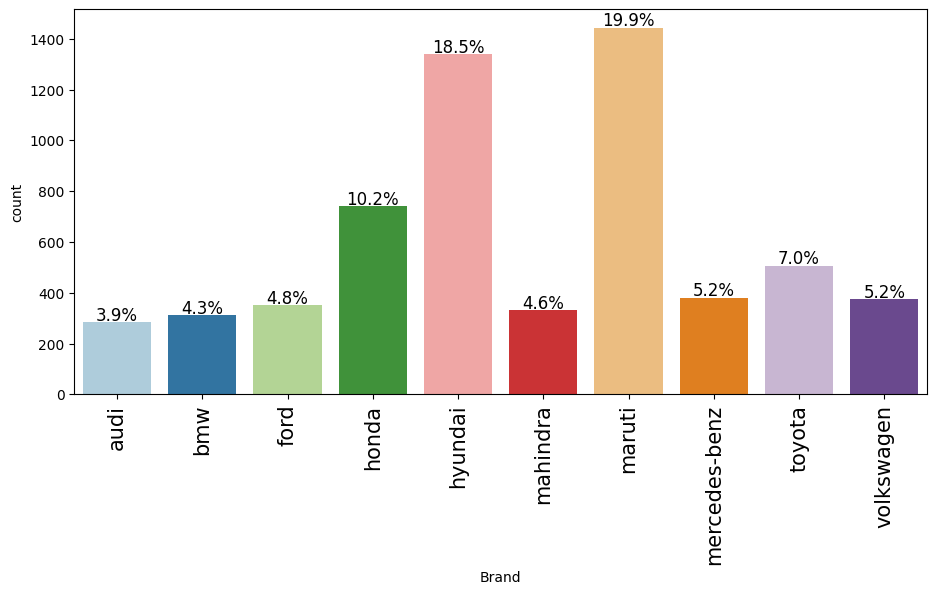

In [ ]:
labeled_barplot(df, "Brand", perc=True, n=10)

Let's check the value counts for the 'Brand' column to verify if 'land' is among the top 10 most frequent brands.

In [ ]:
print(df['Brand'].value_counts().head()) # Display top 15 to check if 'land' appears

Brand
maruti           1443
hyundai          1340
honda             741
toyota            507
mercedes-benz     380
Name: count, dtype: int64


In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
        },
        index=[0],
    )

    return df_perf

In [ ]:
# defining the dependent and independent variables
X = df.drop(["Price"], axis=1)
y = df["Price"]

In [ ]:
# creating dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True,
)

X = X.astype(float)

X.head()

,Year,Kilometers_Driven,Seats,New_Price,mileage_num,engine_num,power_num,Location_Bangalore,Location_Chennai,Location_Coimbatore,...,Model_xenon,Model_xf,Model_xj,Model_xuv300,Model_xuv500,Model_xylo,Model_yeti,Model_z4,Model_zen,Model_zest
0,2010.0,72000.0,5.0,5.51,26.60,998.0,58.16,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015.0,41000.0,5.0,16.06,19.67,1582.0,126.20,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2011.0,46000.0,5.0,8.61,18.20,1199.0,88.70,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2012.0,87000.0,7.0,11.27,20.77,1248.0,88.76,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2013.0,40670.0,5.0,53.14,15.20,1968.0,140.80,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X.shape

(7226, 264)

In [ ]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 5058
Number of rows in test data = 2168


In [ ]:
# fitting a linear model
lin_reg_model1 = LinearRegression()
lin_reg_model1.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Checking model performance on train set
print("Training Performance:")
lin_reg_model1_perf_train = model_performance_regression(
    lin_reg_model1, x_train, y_train
)
lin_reg_model1_perf_train

Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,3.962598,2.108954,0.865101,0.857671


In [ ]:
# Checking model performance on test set
print("Test Performance:")
lin_reg_model1_perf_test = model_performance_regression(lin_reg_model1, x_test, y_test)
lin_reg_model1_perf_test

Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,4.361579,2.215003,0.838262,0.815824
